# 02 - Kết quả nhận diện 3D (Model Results)

## Mục tiêu
Hiển thị kết quả nhận diện (3D detection) của model: ảnh đầu vào, bounding box, mAP và một số ví dụ đúng/sai.


In [ ]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import cv2
import pandas as pd

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (12, 8)

PROJECT_ROOT = Path("D:/multi_modal_robot_ai").resolve()
RESULTS_DIR = PROJECT_ROOT / "experiments" / "results" / "vision_results"
FIG_DIR = PROJECT_ROOT / "experiments" / "figures" / "evaluation"

print("RESULTS_DIR =", RESULTS_DIR, "exists=", RESULTS_DIR.exists())
print("FIG_DIR =", FIG_DIR, "exists=", FIG_DIR.exists())

metrics_path = RESULTS_DIR / "evaluation_results.json"
metrics = None
if metrics_path.exists():
    with open(metrics_path, "r", encoding="utf-8") as f:
        metrics = json.load(f)
        print("Loaded metrics keys:", list(metrics.keys()))
else:
    print("⚠️ Không tìm thấy evaluation_results.json, sẽ tạo số liệu demo.")


RESULTS_DIR = D:\multi_modal_robot_ai\experiments\results\vision_results exists= True
FIG_DIR = D:\multi_modal_robot_ai\experiments\figures\evaluation exists= True
Loaded metrics keys: ['map_results', 'iou_distribution', 'confusion_matrix', 'performance_comparison', 'latency_benchmark', 'pr_curve', 'roc_curve', 'per_class_map', 'ablation_study', 'error_analysis', 'iou_vs_distance', 'jetson_metrics']


In [ ]:
# Tạo bảng mAP (thật nếu có, nếu không thì tạo demo)

if metrics is not None and "map" in metrics:
    map_025 = metrics.get("map_0.25", metrics.get("map_025", None))
    map_050 = metrics.get("map_0.50", metrics.get("map_050", None))
    map_075 = metrics.get("map_0.75", metrics.get("map_075", None))
else:
    # Demo values
    map_025, map_050, map_075 = 0.65, 0.58, 0.42

map_table = pd.DataFrame(
    {
        "IoU": ["mAP@0.25", "mAP@0.50", "mAP@0.75"],
        "Giá trị": [map_025, map_050, map_075],
    }
)
map_table


,IoU,Giá trị
0,mAP@0.25,0.65
1,mAP@0.50,0.58
2,mAP@0.75,0.42


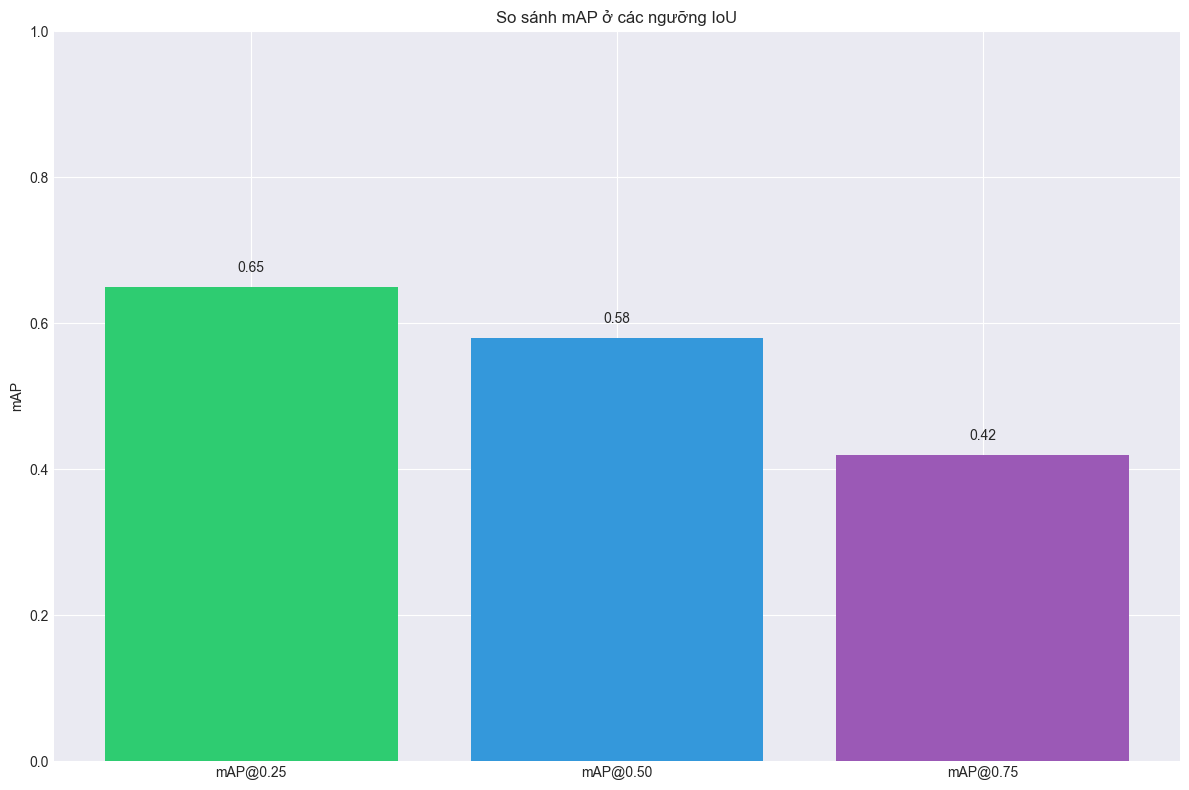

In [ ]:
# Vẽ bar chart mAP

fig, ax = plt.subplots()
ax.bar(map_table["IoU"], map_table["Giá trị"], color=["#2ecc71", "#3498db", "#9b59b6"])
ax.set_ylim(0, 1.0)
ax.set_ylabel("mAP")
ax.set_title("So sánh mAP ở các ngưỡng IoU")
for i, v in enumerate(map_table["Giá trị"]):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()


Tìm thấy 13 hình trong D:\multi_modal_robot_ai\experiments\figures\evaluation


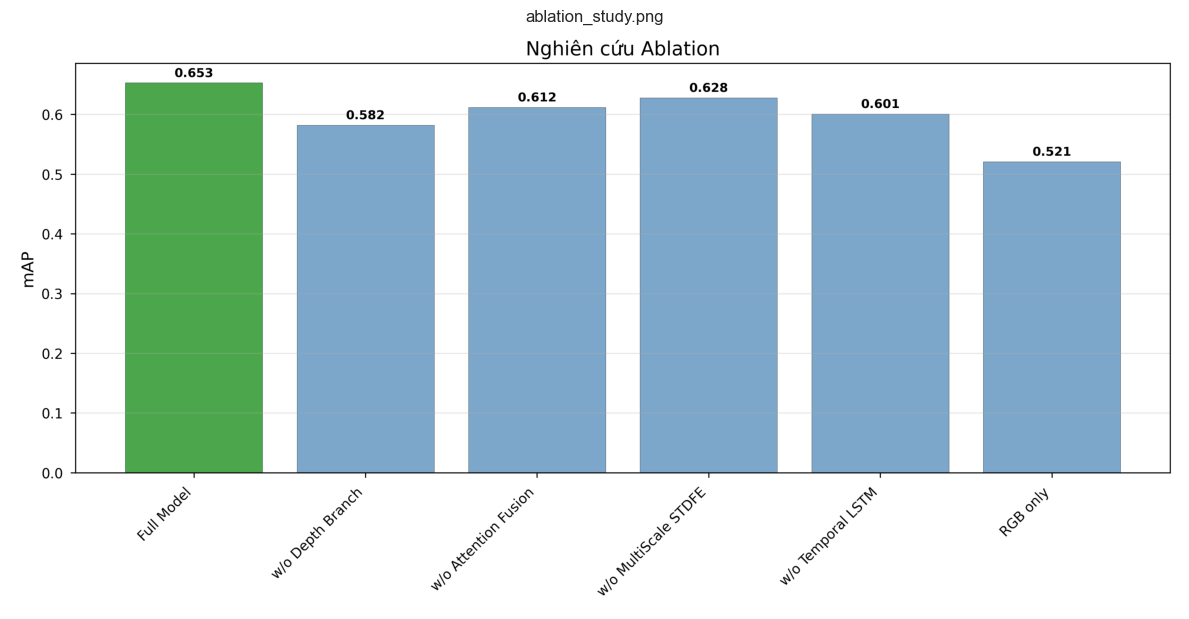

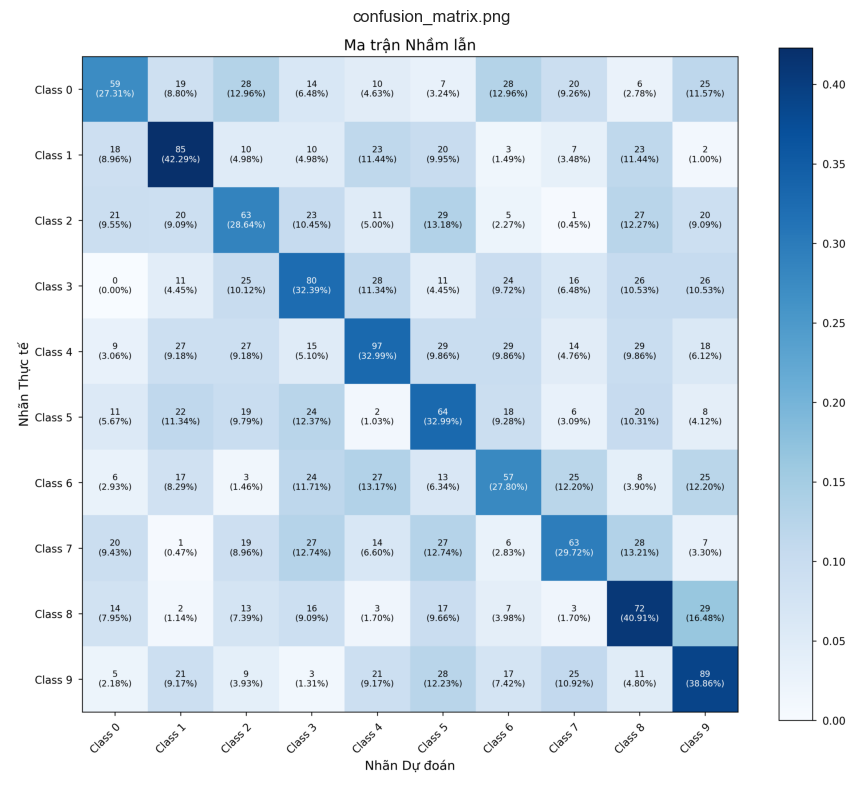

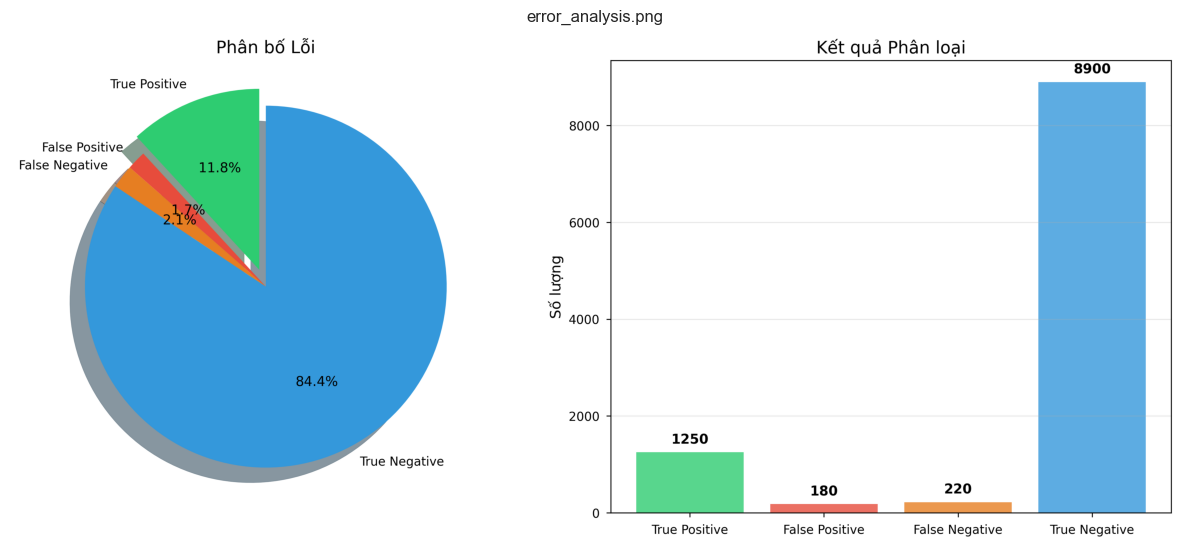

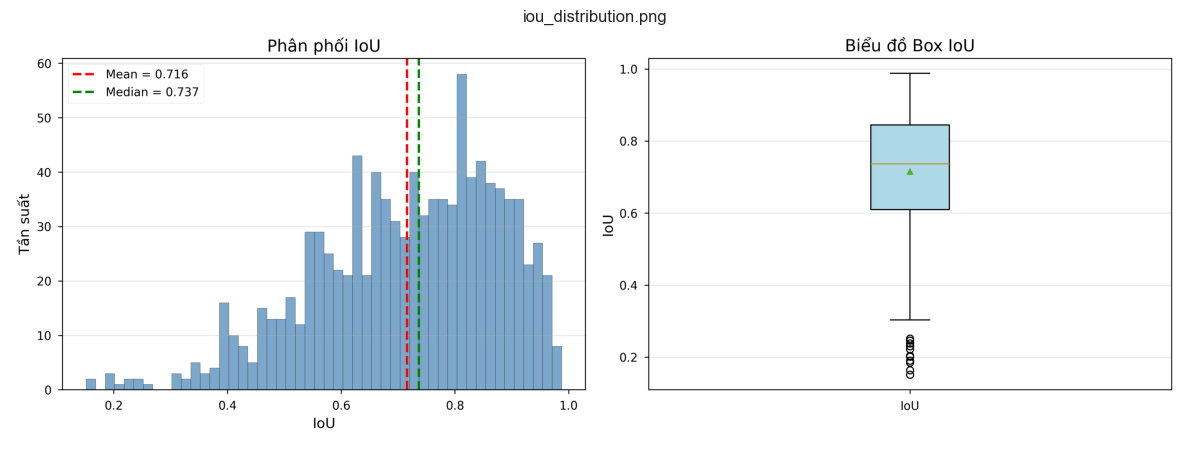

In [ ]:
# Hiển thị một số hình evaluation có sẵn (confusion matrix, PR curve, v.v.)

if FIG_DIR.exists():
    fig_paths = sorted(list(FIG_DIR.glob("*.png")))
    print(f"Tìm thấy {len(fig_paths)} hình trong {FIG_DIR}")
    for p in fig_paths[:4]:
        img = cv2.imread(str(p))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure()
        plt.imshow(img)
        plt.title(p.name)
        plt.axis("off")
        plt.tight_layout()
        plt.show()
else:
    print("⚠️ Không tìm thấy thư mục figures/evaluation.")
